In [1]:
gold_source = "/home/baptvit/Documents/mestrado/master-experiments/evaluations/data/silver/peformance"

In [2]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

all_dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df["consumer_id"] = file.split("/")[-1]
    all_dfs.append(df)


df_silver = pd.concat(all_dfs, ignore_index=True)

In [3]:
df_silver.head()

,Unnamed: 0,experiment_id,timestamp_output_step,full_response,system_promt,input,output,timestamp_search_step,latency_s,query,...,timestamp_tool_step,records,caracteres_count,pass_map_reduce,resource_type,main_keys,user_query,llm_token_limit,strategy_name,consumer_id
0,0,Q1:gemini-1.5-pro:lexical_search_1_hop,2024-12-17 09:32:33,"{'input': ""What's my current medications and h...",\nAs an expert in interpreting Electronic Heal...,What's my current medications and how should I...,Your current medication is **Jolivette 28 Day ...,2024-12-17 09:32:30,0.136163,MATCH (n)\n WHERE toLower(n.nam...,...,2024-12-17 09:32:30,{'Main health record': 'Medication request sta...,30739,False,MedicationRequest,NaN,NaN,1000000,LexicalSearch1HopStrategy,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...
1,1,Q2:gemini-1.5-pro:lexical_search_1_hop,2024-12-16 17:07:13,"{'input': 'What are my documented allergies, a...",\nAs an expert in interpreting Electronic Heal...,"What are my documented allergies, and how seve...",I do not see any documented allergies for you ...,2024-12-16 17:07:13,0.067413,MATCH (n)\n WHERE toLower(n.nam...,...,2024-12-16 17:07:13,NaN,0,False,AllergyIntolerance,NaN,NaN,1000000,LexicalSearch1HopStrategy,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...
2,2,Q3:gemini-1.5-pro:lexical_search_1_hop,2024-12-16 17:08:38,{'input': 'Can you summarize my current medica...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my current medical conditions ?,This is a summary of your medical conditions:\...,2024-12-16 17:07:19,0.045066,MATCH (n)\n WHERE toLower(n.nam...,...,2024-12-16 17:07:19,{'Main health record': 'Clinical Status: Resol...,217498,False,Condition,NaN,NaN,1000000,LexicalSearch1HopStrategy,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...
3,3,Q4:gemini-1.5-pro:lexical_search_1_hop,2024-12-16 17:08:53,{'input': 'What are my recent laboratory value...,\nAs an expert in interpreting Electronic Heal...,"What are my recent laboratory values, what do ...",I lack access to specific lab values or the me...,2024-12-16 17:08:44,0.021563,MATCH (n)\n WHERE toLower(n.nam...,...,2024-12-16 17:08:44,{'Main health record': 'Resource Type: Diagnos...,126725,False,DiagnosticReport,NaN,NaN,1000000,LexicalSearch1HopStrategy,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...
4,4,Q5:gemini-1.5-pro:lexical_search_1_hop,2024-12-16 17:09:33,{'input': 'Can you summarize my care plan hist...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my care plan history ?,You have four care plans in your record:\n\n**...,2024-12-16 17:08:59,0.015176,MATCH (n)\n WHERE toLower(n.nam...,...,2024-12-16 17:08:59,{'Main health record': 'Resource Type: CarePla...,11147,False,CarePlan,NaN,NaN,1000000,LexicalSearch1HopStrategy,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...


In [4]:
df_silver.columns

Index(['Unnamed: 0', 'experiment_id', 'timestamp_output_step', 'full_response',
       'system_promt', 'input', 'output', 'timestamp_search_step', 'latency_s',
       'query', 'similarity_threshold', 'k', 'embedding_model',
       'timestamp_token_step', 'total_cost', 'total_tokens',
       'successful_requests', 'completion_tokens', 'prompt_tokens',
       'total_time', 'timestamp_tool_step', 'records', 'caracteres_count',
       'pass_map_reduce', 'resource_type', 'main_keys', 'user_query',
       'llm_token_limit', 'strategy_name', 'consumer_id'],
      dtype='object')

In [5]:
df = df_silver[
    ["consumer_id", "experiment_id", "strategy_name", "total_time", "total_tokens"]
]

In [6]:
df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)

/tmp/ipykernel_6358/2797313663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['question', 'model', 'search_type']] = df['experiment_id'].str.split(':', expand=True)
/tmp/ipykernel_6358/2797313663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['question', 'model', 'search_type']] = df['experiment_id'].str.split(':', expand=True)
/tmp/ipykernel_6358/2797313663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [7]:
df = df[["consumer_id", "model", "search_type", "question", "total_time", "total_tokens"]]

In [8]:
df.head().to_dict()

{'consumer_id': {0: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d.csv',
  1: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d.csv',
  2: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d.csv',
  3: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d.csv',
  4: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d.csv'},
 'model': {0: 'gemini-1.5-pro',
  1: 'gemini-1.5-pro',
  2: 'gemini-1.5-pro',
  3: 'gemini-1.5-pro',
  4: 'gemini-1.5-pro'},
 'search_type': {0: 'lexical_search_1_hop',
  1: 'lexical_search_1_hop',
  2: 'lexical_search_1_hop',
  3: 'lexical_search_1_hop',
  4: 'lexical_search_1_hop'},
 'question': {0: 'Q1', 1: 'Q2', 2: 'Q3', 3: 'Q4', 4: 'Q5'},
 'total_time': {0: 7.147480249404907,
  1: 4.457610607147217,
  2: 82.4694972038269,
  3: 13.080258131027222,
  4: 38.30955314636231},
 'total_tokens': {0: 12373, 1: 1005, 2: 73785, 3: 45148, 4: 6640}}

In [9]:
# Basic statistical analysis
statistics = df[["total_time", "total_tokens"]].describe()

# Adding custom percentiles
percentiles = df[["total_time", "total_tokens"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
percentiles.columns = ["5%", "25%", "50%", "75%", "95%"]

# Calculating variance
variance = df[["total_time", "total_tokens"]].var()

# Calculating additional statistics (if needed)
skewness = df[["total_time", "total_tokens"]].skew()
kurtosis = df[["total_time", "total_tokens"]].kurt()

# Combine results into a single DataFrame for better overview
detailed_stats = pd.concat(
    [
        statistics.T,
        percentiles,
        variance.rename("variance"),
        skewness.rename("skewness"),
        kurtosis.rename("kurtosis"),
    ],
    axis=1,
)

# Display the results
print(detailed_stats)

              count          mean            std         min          25%  \
total_time    160.0     29.675534      35.832651    3.935503     8.428207   
total_tokens  160.0  57645.062500  116476.788570  999.000000  3351.250000   

                      50%           75%            max         5%  \
total_time       13.49851     29.944983     171.892427     4.3863   
total_tokens  12638.50000  45998.250000  786994.000000  1034.0000   

                      25%          50%           75%            95%  \
total_time       8.428207     13.49851     29.944983     109.824095   
total_tokens  3351.250000  12638.50000  45998.250000  281794.900000   

                  variance  skewness   kurtosis  
total_time    1.283979e+03  1.939163   3.019445  
total_tokens  1.356684e+10  3.591628  15.560042  


In [10]:
df[["search_type", "total_time", "total_tokens"]].describe()

,total_time,total_tokens
count,160.000000,160.00000
mean,29.675534,57645.06250
std,35.832651,116476.78857
min,3.935503,999.00000
25%,8.428207,3351.25000
50%,13.498510,12638.50000
75%,29.944983,45998.25000
max,171.892427,786994.00000


# Per search type

In [20]:
analysis = (
    df.groupby("search_type")
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .reset_index()
)

analysis

,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,L0,22.535266,29.310617,4.058216,8.757763,12.710777,20.123198,123.374901,13479.025,18994.142428,999,2490.25,5414.0,14449.75,81662
1,L1,49.035484,46.239278,4.094568,10.297751,25.453432,83.343365,171.892427,84921.750,113034.301044,1005,9088.75,28991.0,115731.75,395997
2,S0,15.107050,19.358590,3.935503,7.107362,10.680835,15.469543,123.820415,25491.625,53732.956931,1034,2821.00,4814.5,15810.50,279085
3,S1,32.024337,34.679894,4.145251,8.843543,18.015841,40.224348,151.662111,106687.850,181645.923993,1032,12721.75,34933.5,87547.50,786994


In [21]:
analysis.to_dict()

{'search_type': {0: 'L0', 1: 'L1', 2: 'S0', 3: 'S1'},
 'total_time_mean': {0: 22.53526594042778,
  1: 49.03548416495323,
  2: 15.107050102949142,
  3: 32.02433699965477},
 'total_time_std': {0: 29.310616838156417,
  1: 46.23927805203337,
  2: 19.358590282259648,
  3: 34.67989352989618},
 'total_time_min': {0: 4.058215618133545,
  1: 4.094568252563477,
  2: 3.935502767562866,
  3: 4.145251035690308},
 'total_time_25th': {0: 8.757762789726257,
  1: 10.297750949859621,
  2: 7.10736209154129,
  3: 8.843543469905853},
 'total_time_median': {0: 12.710777401924133,
  1: 25.453432083129883,
  2: 10.680834531784058,
  3: 18.015840768814087},
 'total_time_75th': {0: 20.123198211193085,
  1: 83.34336549043655,
  2: 15.469542860984802,
  3: 40.22434765100479},
 'total_time_max': {0: 123.37490105628969,
  1: 171.892427444458,
  2: 123.820415019989,
  3: 151.66211104393005},
 'total_tokens_mean': {0: 13479.025, 1: 84921.75, 2: 25491.625, 3: 106687.85},
 'total_tokens_std': {0: 18994.142428367293,
  

In [12]:
df = df.sort_values(by=["search_type"], ascending=True)

/tmp/ipykernel_6358/2784806866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='search_type', y='total_time', palette='Set2', legend=False)
/tmp/ipykernel_6358/2784806866.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='search_type', y='total_tokens', palette='Set2', legend=False)


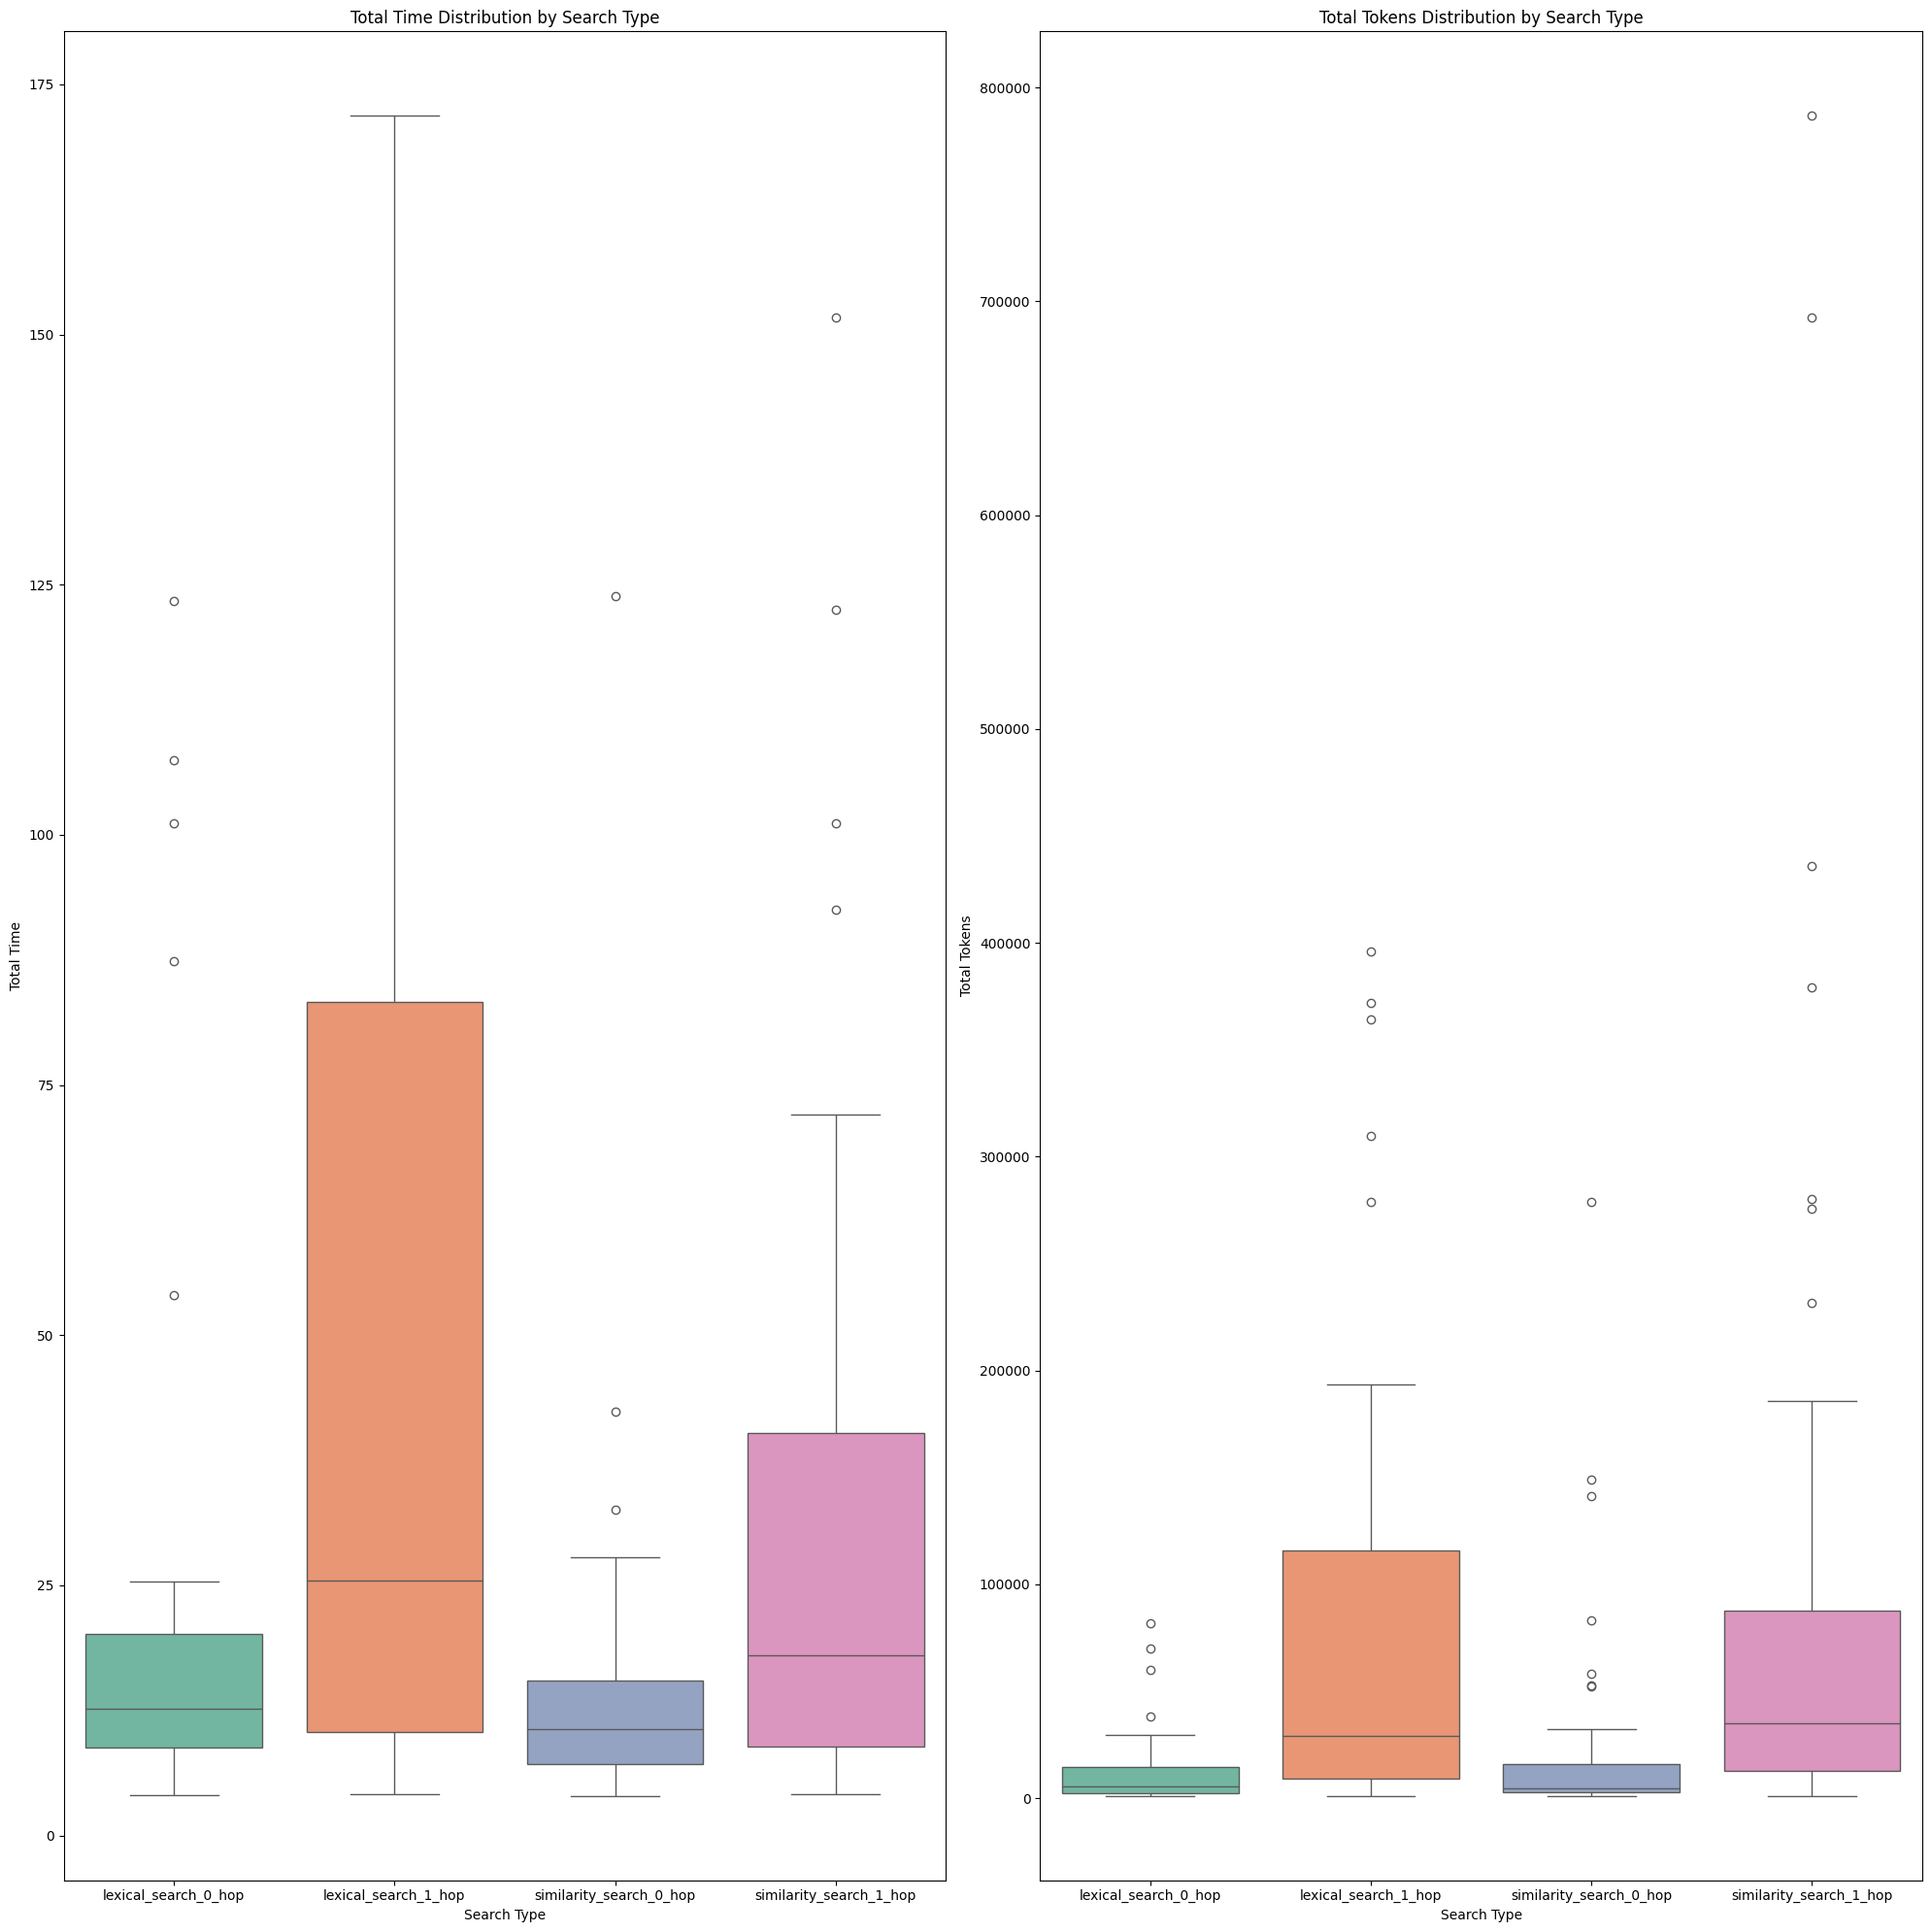

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
plt.title("Total Time Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Time")
plt.tight_layout()
# plt.xticks([])

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)
plt.title("Total Tokens Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Tokens")
# plt.legend(['Lexical Search', 'Similarity Search'], loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=True, ncol=5)

plt.tight_layout()

plt.show()

/tmp/ipykernel_6358/1577265955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df, x='search_type', y='total_time', palette='coolwarm')
/tmp/ipykernel_6358/1577265955.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(data=df, x='search_type', y='total_tokens', palette='coolwarm')


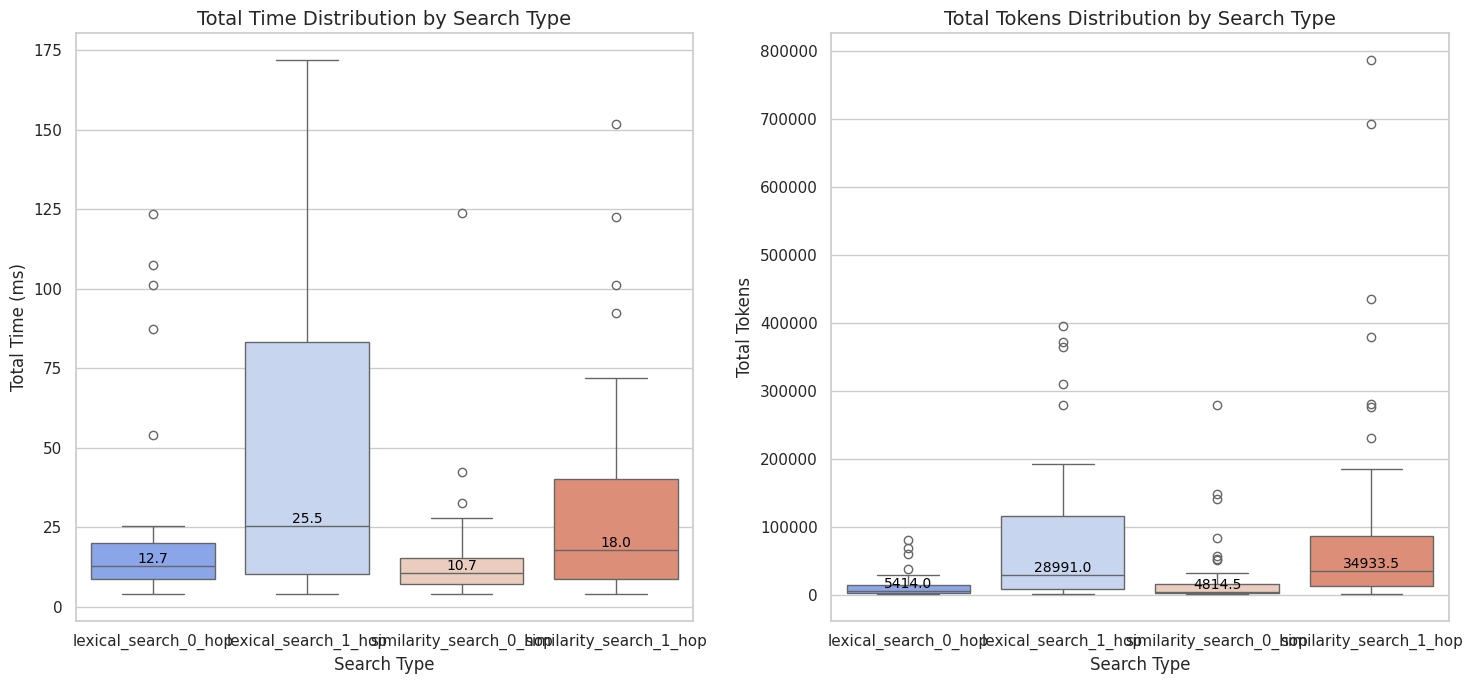

In [15]:
# Set general style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(15, 7))

# Box plot for total_time
plt.subplot(1, 2, 1)
ax1 = sns.boxplot(data=df, x="search_type", y="total_time", palette="coolwarm")
plt.title("Total Time Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Time (ms)", fontsize=12)

# Add median value annotations
medians_time = df.groupby("search_type")["total_time"].median().reset_index()
for idx, row in medians_time.iterrows():
    plt.text(
        x=idx,
        y=row["total_time"],
        s=f"{row['total_time']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Box plot for total_tokens
plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x="search_type", y="total_tokens", palette="coolwarm")
plt.title("Total Tokens Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Tokens", fontsize=12)

# Add median value annotations
medians_tokens = df.groupby("search_type")["total_tokens"].median().reset_index()
for idx, row in medians_tokens.iterrows():
    plt.text(
        x=idx,
        y=row["total_tokens"],
        s=f"{row['total_tokens']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [16]:
dict_map = {
    "lexical_search_0_hop": "L0",
    "lexical_search_1_hop": "L1",
    "similarity_search_0_hop": "S0",
    "similarity_search_1_hop": "S1",
}
df = df.replace({"search_type": dict_map})

In [17]:
df.head()

,consumer_id,model,search_type,question,total_time,total_tokens
83,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,gemini-1.5-pro,L0,Q6,8.128603,10919
85,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,gemini-1.5-pro,L0,Q3,12.740262,3266
84,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,gemini-1.5-pro,L0,Q7,13.154393,3322
53,Allen322_Ferry570_ad134528-56a5-35fd-c37f-466f...,gemini-1.5-pro,L0,Q6,107.434301,81662
82,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...,gemini-1.5-pro,L0,Q2,10.275117,1978


/tmp/ipykernel_6358/448728763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='search_type', y='total_time', palette='Set2', showfliers=True)
/tmp/ipykernel_6358/448728763.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='search_type', y='total_tokens', palette='Set2', showfliers=True)


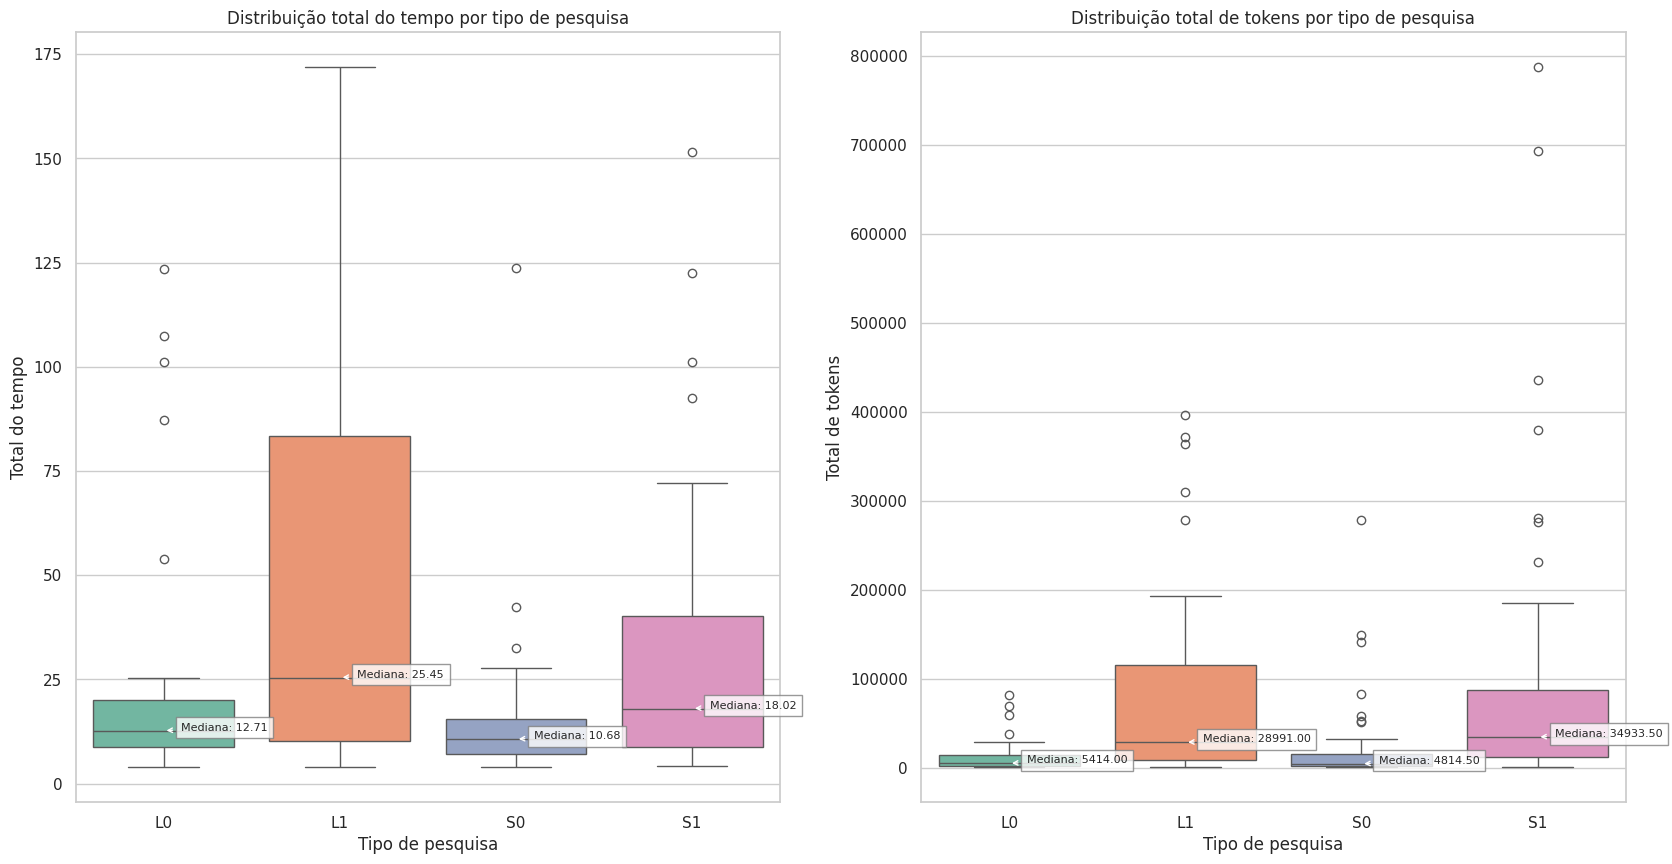

In [33]:
# Adjust the figure size for better layout
plt.figure(figsize=(20, 10))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", showfliers=True)
plt.title("Distribuição total do tempo por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total do tempo")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_time"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", showfliers=True)
plt.title("Distribuição total de tokens por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total de tokens")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_tokens"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# plt.tight_layout()
plt.show()